In [1]:
!pip -q install transformers datasets accelerate evaluate scikit-learn


In [2]:
import pandas as pd

df = pd.read_csv("/content/dataset_ansiedade_vs_nao_balanceado.csv")
print(df.head())
print("\nDistribuição:")
print(df["label"].value_counts())
print("\nColunas:", df.columns)

                                                text          label  label_id
0               derrubei coca cola na minha apostila  nao_ansiedade         0
1                          O meu header é só lindo )  nao_ansiedade         0
2  esse é o verdadeiro bolsonaro, não fala nada e...      ansiedade         1
3  Sempre quis encontrar alguém que pudesse falar...  nao_ansiedade         0
4                   to precisando muito de uma praia      ansiedade         1

Distribuição:
label
nao_ansiedade    569
ansiedade        569
Name: count, dtype: int64

Colunas: Index(['text', 'label', 'label_id'], dtype='object')


In [3]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

print("Treino:", train_df["label"].value_counts().to_dict())
print("Teste:", test_df["label"].value_counts().to_dict())


Treino: {'nao_ansiedade': 455, 'ansiedade': 455}
Teste: {'ansiedade': 114, 'nao_ansiedade': 114}


In [4]:
!pip -q install -U transformers accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 24.9 MB/s eta 0:00:00


In [5]:
from datasets import Dataset
from transformers import AutoTokenizer

model_name = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_ds = Dataset.from_pandas(train_df[["text", "label_id"]].rename(columns={"label_id":"labels"}))
test_ds  = Dataset.from_pandas(test_df[["text", "label_id"]].rename(columns={"label_id":"labels"}))

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

train_tok = train_ds.map(tokenize, batched=True)
test_tok  = test_ds.map(tokenize, batched=True)

train_tok = train_tok.remove_columns(["text"])
test_tok  = test_tok.remove_columns(["text"])

train_tok.set_format("torch")
test_tok.set_format("torch")

print("✅ Tokenização pronta")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/910 [00:00<?, ? examples/s]

Map:   0%|          | 0/228 [00:00<?, ? examples/s]

✅ Tokenização pronta


In [6]:
import numpy as np
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

id2label = {0:"nao_ansiedade", 1:"ansiedade"}
label2id = {"nao_ansiedade":0, "ansiedade":1}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
        "f1_weighted": f1.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }

try:
    training_args = TrainingArguments(
        output_dir="bertimbau_ansiedade_novo",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=1e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=6,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        logging_steps=50,
        report_to="none"
    )
except TypeError:
    training_args = TrainingArguments(
        output_dir="bertimbau_ansiedade_novo",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=1e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=6,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        logging_steps=50,
        report_to="none"
    )

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    compute_metrics=compute_metrics
)

trainer.train()


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.644489,0.529340,0.798246,0.798183,0.798183
2,0.430308,0.312926,0.855263,0.855037,0.855037
3,0.258664,0.282891,0.881579,0.881394,0.881394
4,0.190705,0.304313,0.881579,0.881303,0.881303
5,0.099786,0.331862,0.881579,0.881303,0.881303
6,0.083662,0.333412,0.885965,0.885745,0.885745


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=342, training_loss=0.25859264463011983, metrics={'train_runtime': 248.8751, 'train_samples_per_second': 21.939, 'train_steps_per_second': 1.374, 'total_flos': 359146590566400.0, 'train_loss': 0.25859264463011983, 'epoch': 6.0})

In [7]:
import torch

def prever_debug(texto, thr=0.50):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, padding=True, max_length=128)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        out = model(**inputs)
        probs = torch.softmax(out.logits, dim=-1).cpu().numpy()[0]

    p_nao, p_ans = float(probs[0]), float(probs[1])
    pred = "ansiedade" if p_ans >= thr else "nao_ansiedade"

    print("Texto:", texto)
    print(f"thr={thr} | P(ansiedade)={p_ans:.3f} | P(nao_ansiedade)={p_nao:.3f}")
    print("Predição:", pred)
    print("-"*80)

testes = [
    "Hoje eu acordei com o coração acelerado e uma sensação de medo sem motivo.",
    "Não consigo parar de pensar no pior, minha mente não desliga.",
    "Estou com uma angústia no peito e pensando que algo ruim vai acontecer.",
    "Vou ali comprar pão e já volto.",
    "Que dia maravilhoso! Estou muito feliz com as notícias de hoje :)"
]

for t in testes:
    prever_debug(t, thr=0.50)


Texto: Hoje eu acordei com o coração acelerado e uma sensação de medo sem motivo.
thr=0.5 | P(ansiedade)=0.976 | P(nao_ansiedade)=0.024
Predição: ansiedade
--------------------------------------------------------------------------------
Texto: Não consigo parar de pensar no pior, minha mente não desliga.
thr=0.5 | P(ansiedade)=0.987 | P(nao_ansiedade)=0.013
Predição: ansiedade
--------------------------------------------------------------------------------
Texto: Estou com uma angústia no peito e pensando que algo ruim vai acontecer.
thr=0.5 | P(ansiedade)=0.982 | P(nao_ansiedade)=0.018
Predição: ansiedade
--------------------------------------------------------------------------------
Texto: Vou ali comprar pão e já volto.
thr=0.5 | P(ansiedade)=0.007 | P(nao_ansiedade)=0.993
Predição: nao_ansiedade
--------------------------------------------------------------------------------
Texto: Que dia maravilhoso! Estou muito feliz com as notícias de hoje :)
thr=0.5 | P(ansiedade)=0.006 | P(n

In [8]:
from sklearn.metrics import classification_report

pred = trainer.predict(test_tok)
y_true = pred.label_ids
y_pred = pred.predictions.argmax(axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=["nao_ansiedade", "ansiedade"]
))


               precision    recall  f1-score   support

nao_ansiedade       0.92      0.84      0.88       114
    ansiedade       0.85      0.93      0.89       114

     accuracy                           0.89       228
    macro avg       0.89      0.89      0.89       228
 weighted avg       0.89      0.89      0.89       228



In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


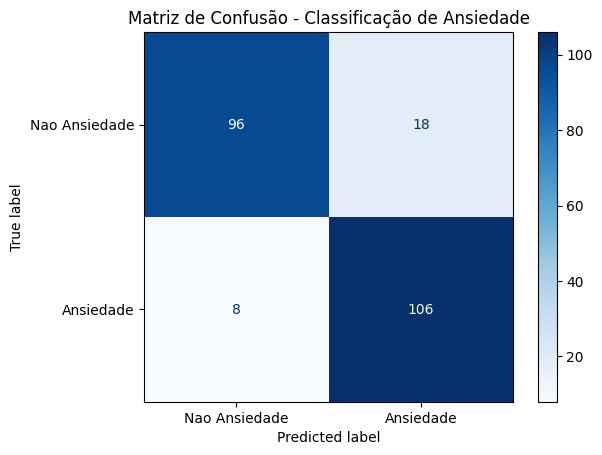

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred = trainer.predict(test_tok)
y_true = pred.label_ids
y_pred = pred.predictions.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Nao Ansiedade", "Ansiedade"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - Classificação de Ansiedade")
plt.show()